# RUN 15107 

Let's look into trigger 2 data from one of the first HE runs.

In [1]:
import glob
import numpy as np
import pandas as pd
import tables as tb

import matplotlib.pyplot as plt

In [2]:
def plot_coord_info(df, run_number, c = ['X', 'Y', 'Z'], 
                    nbins = [60, 60, 60, 100], 
                    hist2d_range = ((-500, 500), (-500, 500)),
                    xlabels = ['X (mm)', 'Y (mm)', 'Z (mm)'], 
                    rad = 480, 
                    title = ''):
    plt.suptitle('RUN-{}'.format(run_number) + title)
    plt.subplot(2, 2, 1)
    plt.hist(df[c[0]], nbins[0])
    plt.xlabel(xlabels[0])
    plt.subplot(2, 2, 2)
    plt.hist(df[c[1]], nbins[1])
    plt.xlabel(xlabels[1])
    plt.subplot(2, 2, 3)
    plt.hist(df[c[2]], nbins[2])
    plt.xlabel(xlabels[2])
    plt.subplot(2, 2, 4)
    hist = plt.hist2d(df[c[0]], df[c[1]], bins=nbins[3], range = hist2d_range, cmap='viridis')
    plt.colorbar(hist[3], label='Counts')
    plt.gca().add_patch(plt.Circle((0, 0), rad, color='r', fill=False, linewidth=1)) 
    plt.xlabel(xlabels[0])
    plt.ylabel(xlabels[1])
    plt.tight_layout()

In [3]:
def plot_s2_info(df, run_number, nbins = (100, 100, 100, 100), xrange = [(0, 500), (0, 150000), (0, 500000)], title = ''):
    plt.suptitle('RUN-{}'.format(run_number) + title)
    plt.subplot(2, 2, 1)
    plt.hist(df.DT, nbins[0])
    plt.xlabel('DT (mus)')

    plt.subplot(2, 2, 2)
    plt.hist(df.S2w, nbins[1], xrange[0])
    plt.xlabel('S2 width')

    plt.subplot(2, 2, 3)
    plt.hist(df.S2q, nbins[2], xrange[1])
    plt.xlabel('S2 charge')

    plt.subplot(2, 2, 4)
    plt.hist(df.S2e, nbins[3], xrange[2])
    plt.xlabel('S2 energy')

    plt.tight_layout()

In [4]:
from scipy.optimize import curve_fit
from scipy.integrate import quad

def gauss(x, a, mu, sigma):
    return a * np.exp(-((x - mu) / sigma) ** 2 / 2)

def expon(x, m, c):
    return m *np.exp(-x/c)

def peak_fit(x, a, mu, sigma, m, c):
    return gauss(x, a, mu, sigma) + expon(x, m, c)

#trashy function, very hard coded
def fit_and_plot_peaks_resolution(data, fun, nbins, plotrange, fitrange, initial_params, bounds, title, density = True):
    y, x = np.histogram(data, nbins, range = plotrange, density = density)
    # from the xbins we select the range to plot, otherwise things don't match
    fit_mask = (x > fitrange[0]) & (x < fitrange[1])
    fit_x, fit_y = x[fit_mask], y[fit_mask[:-1]]
    params, cov = curve_fit(fun, fit_x, fit_y, p0=initial_params, bounds = bounds, maxfev = 2000)
    a, mu, sigma, m, c = params[0], params[1], params[2], params[3], params[4]
    yfit = fun(fit_x, a, mu, sigma, m, c)

    R = 2 * np.sqrt(2 * np.log(2)) * sigma * 100 / mu
    sR = R * np.sqrt((cov[2, 2] / sigma) **2 + (cov[1, 1]/mu)**2)

    legend_string = r'$\mu={:.3f} \pm {:.3e}$'.format(mu, cov[1,1]) + '\n' + \
                    r'$\sigma={:.3f} \pm {:.3e}$'.format(sigma, cov[2,2]) + '\n' + \
                    r'R(%) = ${:.3f} \pm {:.3e}$'.format(R, sR)
    plt.hist(data, nbins, range = plotrange, histtype='step', density = density)
    plt.plot(fit_x, yfit, 'r-', label = legend_string)
    plt.legend()
    plt.xlabel('E (MeV)')
    if density:
        plt.ylabel('Probability density (1 / MeV)')
    else:
        plt.ylabel('Events')
    plt.title(title)
    plt.grid()
    plt.show()
    return params, R

In [33]:
run_number = 15107
path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/runs/{run_number}/'.format(run_number = run_number)

data_path = path + '*/*'
save_path = path + 'all_info.h5' #'dst.h5'
save_path_clean = path + 'all_info_clean.h5' #'all_info.h5' #'dst.h5'
save_path_summary = path + 'all_info_summary.h5'

files = sorted(glob.glob(data_path + '*'), key=lambda x: (x.split('/')[-2], int(x.split('/')[-1].split('_')[2])))

In [34]:
dst = pd.read_hdf(save_path_summary, 'DST/Events')
reco_summ = pd.read_hdf(save_path_summary, 'RECO/Events_summary')

In [74]:
reco_summ

,event,npeak,dX,dY,dZ,X_bary,Y_bary,Z_bary,total_energy,num_hits
0,156,4,926.00,941.55,107.705625,291.137833,48.385796,-211.800064,0.466323,605.0
1,156,16,957.10,957.10,103.851875,234.730681,-128.325753,799.840647,0.601568,878.0
2,275,3,941.55,894.90,121.966250,28.708609,-153.827445,200.056184,0.745806,783.0
3,317,4,941.55,910.45,59.131687,146.315026,-24.024491,-4.502623,0.132493,146.0
4,317,12,926.00,848.75,64.224250,138.550281,288.066607,454.527914,0.025331,38.0
...,...,...,...,...,...,...,...,...,...,...
4,1543611,11,941.55,957.10,65.860719,-78.221234,106.761913,30.526851,0.116165,230.0
5,1543611,34,910.45,894.90,95.486875,-25.533748,245.984778,1015.528444,0.281955,240.0
6,1543639,1,957.10,972.65,157.661250,-181.176193,-260.373339,543.114826,1.514937,1964.0
7,1543695,20,926.00,972.65,96.194500,-314.793696,-298.092817,442.032764,0.739055,582.0


* Profile entre energía / numero hits, dx, dy, dz
* A posteriori juntar varios runes
* plot radio vs energía (en histograma 2d)
* Añadir columna eficiencia 1S1, y 1S1 + 1S2 + DS peak

In [35]:
print('# events:', len(dst.event.unique()))

print('CUT: 0 < DT < 1500')

clean_dst = dst[(dst.DT > 0) & (dst.DT < 1500)].copy()
print('DST # events:', len(clean_dst.event.unique()))

# events: 67969
CUT: 0 < DT < 1500
DST # events: 61712


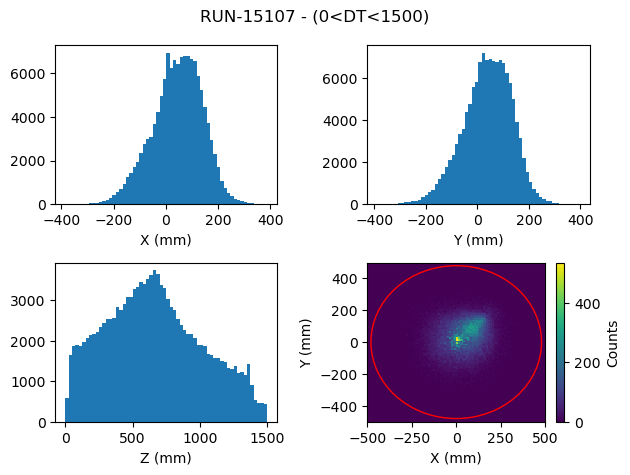

In [36]:
plot_coord_info(clean_dst,run_number, title = ' - (0<DT<1500)')

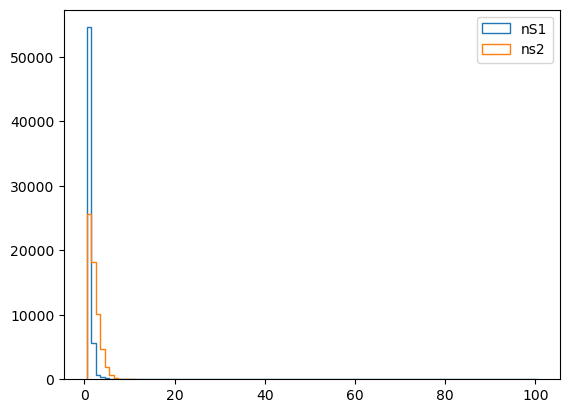

In [37]:
nsignal = clean_dst[['event', 'nS1', 'nS2']].drop_duplicates()
plt.hist(nsignal.nS1, max(nsignal.nS1), range=(0.5, max(nsignal.nS1) + 0.5), histtype='step', label = 'nS1')
plt.hist(nsignal.nS2, max(nsignal.nS2), range=(0.5, max(nsignal.nS2) + 0.5), histtype='step', label = 'ns2')
plt.legend()

In [38]:
print('CUT: nS1 < 15')
clean_dst = clean_dst[clean_dst.nS1 < 15]
print('# events:', len(clean_dst.event.unique()))

CUT: nS1 < 15
# events: 61647


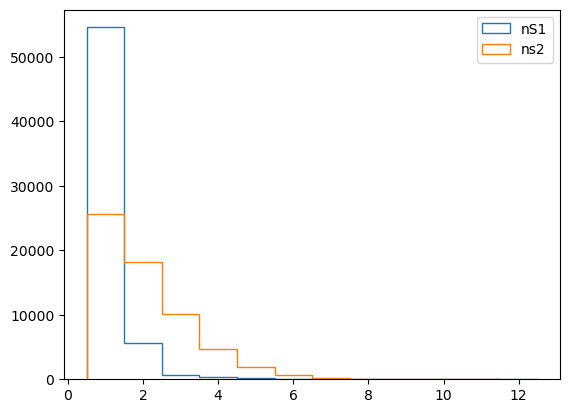

In [39]:
nsignal = clean_dst[['event', 'nS1', 'nS2']].drop_duplicates()
plt.hist(nsignal.nS1, max(nsignal.nS1), range=(0.5, max(nsignal.nS1) + 0.5), histtype='step', label = 'nS1')
plt.hist(nsignal.nS2, max(nsignal.nS2), range=(0.5, max(nsignal.nS2) + 0.5), histtype='step', label = 'ns2')
plt.legend()

Seleccionamos los eventos con un solo S1 para ver cómo son sus S2

In [41]:
ones1_dst = clean_dst[(clean_dst.nS1 == 1)]
ones1_dst = clean_dst[(clean_dst.nS2 == 1)]
print('CUT: 1S1 & 1S2')
print('# events:', len(ones1_dst.event.unique()))

CUT: 1S1 & 1S2
# events: 25627


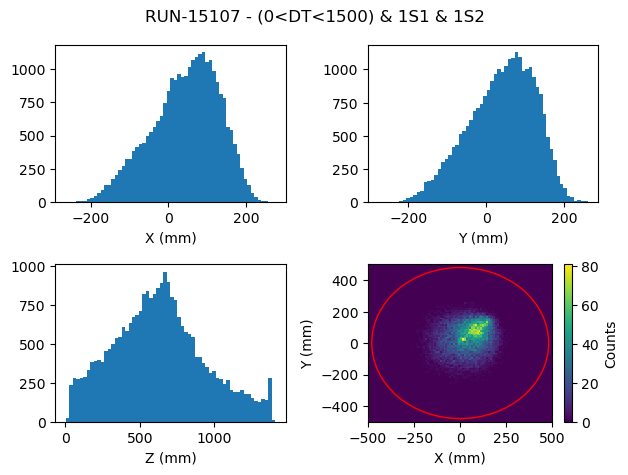

In [42]:
plot_coord_info(ones1_dst, run_number, title=' - (0<DT<1500) & 1S1 & 1S2')

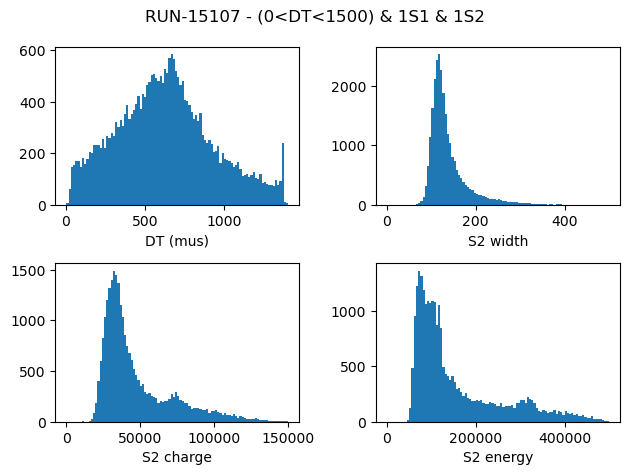

In [43]:
plot_s2_info(ones1_dst, run_number, title=' - (0<DT<1500) & 1S1 & 1S2')

In [44]:
print('CUT: 200k<S2e<400k')
s2e_dst = ones1_dst[(ones1_dst.S2e > 200000) & (ones1_dst.S2e < 400000)]
print('# events:', len(ones1_dst.event.unique()))


CUT: 200k<S2e<400k
# events: 25627


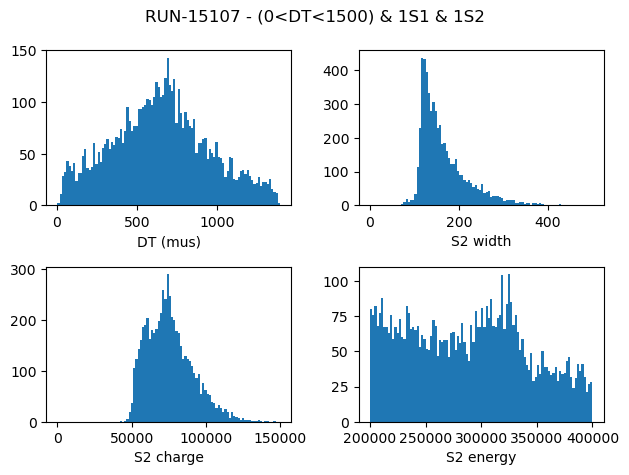

In [45]:
plot_s2_info(s2e_dst, run_number, title=' - (0<DT<1500) & 1S1 & 1S2', xrange=[(0, 500), (0, 150000), (200000, 400000)])

Text(0, 0.5, 'S2 energy (pes)')

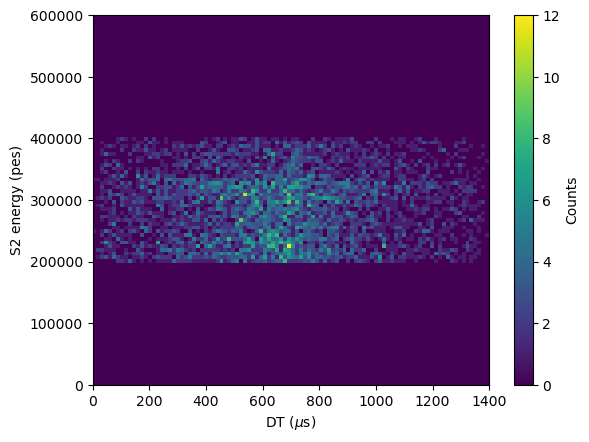

In [46]:
hist = plt.hist2d(s2e_dst.DT, s2e_dst.S2e, bins = 100, range = ((0, 1400), (0, 600000)), cmap='viridis')
plt.colorbar(hist[3], label='Counts')

plt.xlabel(r'DT ($\mu$s)')
plt.ylabel('S2 energy (pes)')

Text(0, 0.5, 'DT$_{rms}^2$ ($\\mu$s$^2$)')

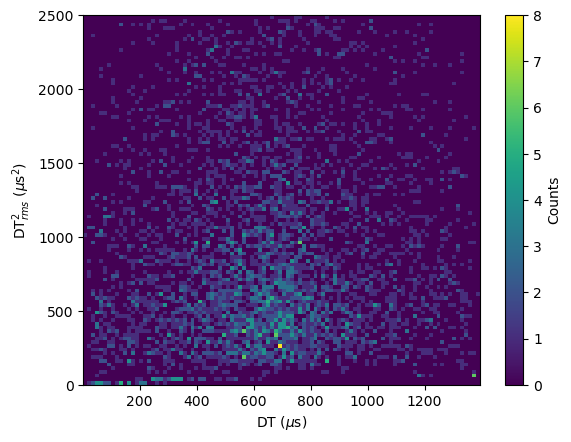

In [47]:
hist = plt.hist2d(s2e_dst.Z, (s2e_dst.Zrms) ** 2, bins=100, range=((min(s2e_dst.Z), max(s2e_dst.Z)), (0, 2500)), cmap='viridis')

plt.colorbar(hist[3], label='Counts')

plt.xlabel('DT ($\mu$s)')
plt.ylabel(r'DT$_{rms}^2$ ($\mu$s$^2$)')

## Summary info from hits

In [48]:
print('CUT: 0 < Z_bary < 1500')
clean_reco_summ = reco_summ[(reco_summ.Z_bary > 0) & (reco_summ.Z_bary < 1500)].copy()
print('RECO # events:', len(clean_dst.event.unique()))

CUT: 0 < Z_bary < 1500
RECO # events: 61647


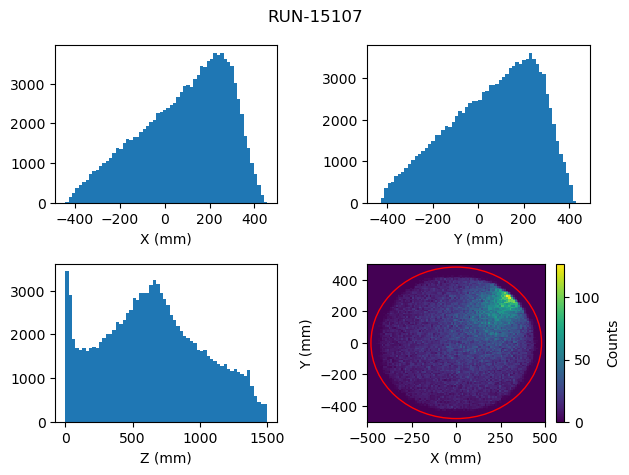

In [49]:
plot_coord_info(clean_reco_summ, run_number, c = ['X_bary', 'Y_bary', 'Z_bary'])

Text(0.5, 0, 'E (MeV)')

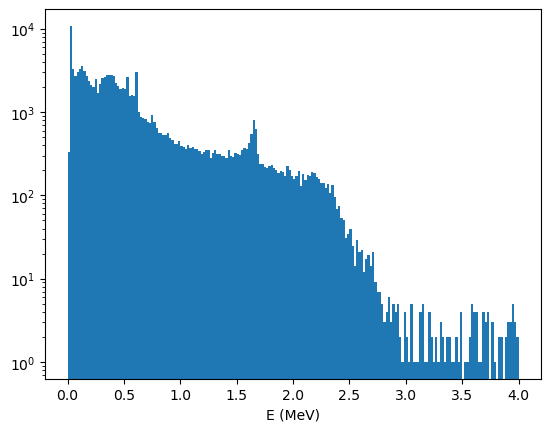

In [51]:
plt.hist(clean_reco_summ.total_energy, 200, (0, 4))
plt.yscale('log')
plt.xlabel('E (MeV)')

Text(0.5, 0, 'E (MeV)')

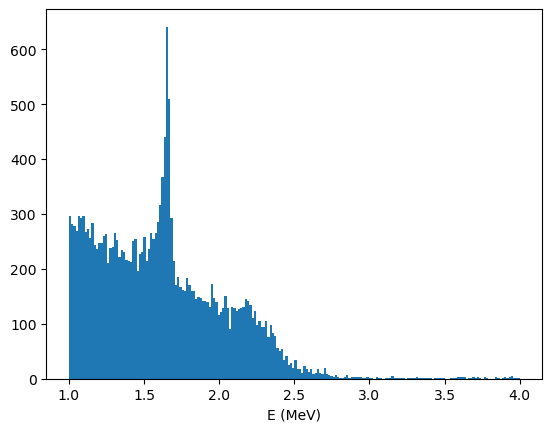

In [52]:
plt.hist(clean_reco_summ.total_energy, 200, (1, 4))
plt.xlabel('E (MeV)')

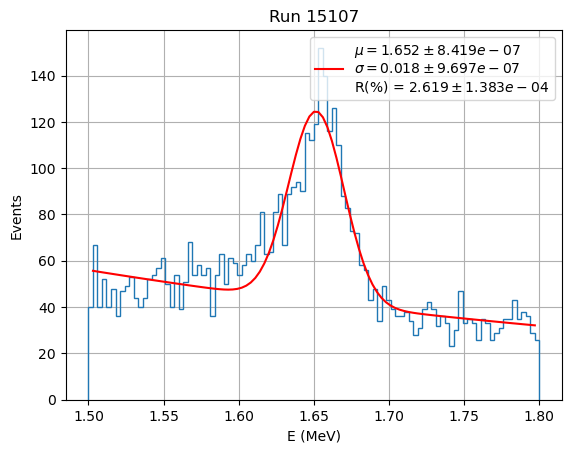

(array([8.24081785e+01, 1.65167095e+00, 1.83668278e-02, 9.26030466e+02,
        5.34567550e-01]),
 2.618595083672838)

In [55]:
rang = (1.5, 1.8)
initial_params = [250, 1.65, 0.02, 1, 7]
bounds = ([0, 0, 0, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])

fit_and_plot_peaks_resolution(clean_reco_summ.total_energy, peak_fit, 100, rang, rang, initial_params, bounds, 'Run {}'.format(run_number), density = False)

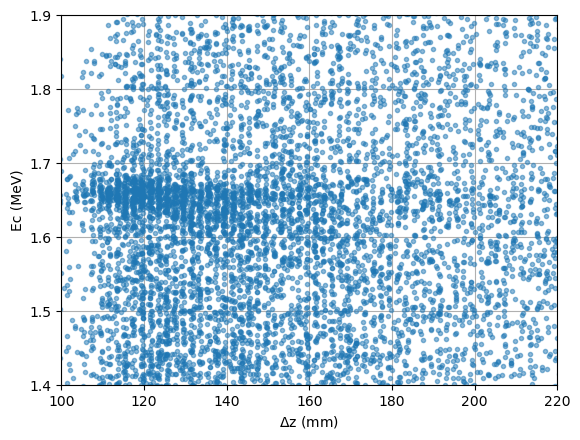

In [54]:
plt.plot(clean_reco_summ.dZ, clean_reco_summ.total_energy, '.', alpha = 0.5)
plt.xlim((100, 220))
plt.ylim((1.4, 1.9))
plt.xlabel(r'$\Delta$z (mm)')
plt.ylabel('Ec (MeV)')
plt.grid()

### Now if we clean using the DST cuts applied before:

In [56]:
cut_dst_events = s2e_dst.event.unique()

final_reco_summ = clean_reco_summ[np.isin(clean_reco_summ.event, cut_dst_events)]

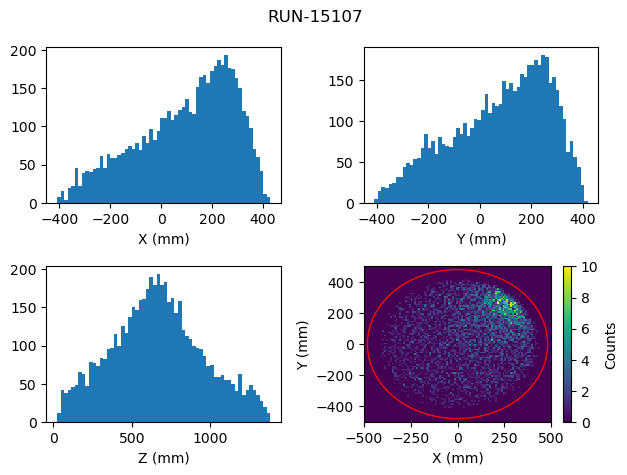

In [57]:
plot_coord_info(final_reco_summ, run_number, c = ['X_bary', 'Y_bary', 'Z_bary'])

Text(0.5, 0, 'E (MeV)')

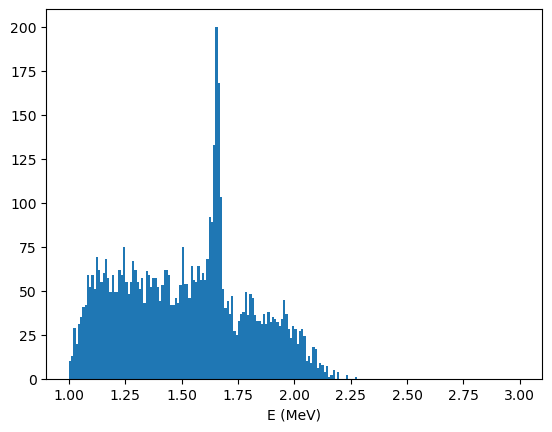

In [58]:
plt.hist(final_reco_summ.total_energy, 200, (1, 3))
plt.xlabel('E (MeV)')

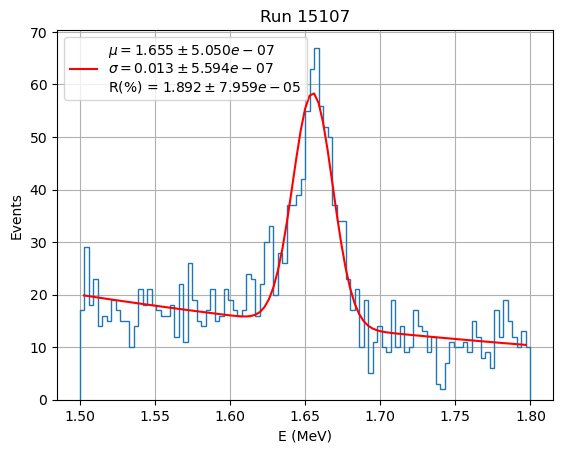

(array([4.41741763e+01, 1.65519278e+00, 1.33011807e-02, 5.32120555e+02,
        4.57013823e-01]),
 1.8923407156343308)

In [59]:
rang = (1.5, 1.8)
initial_params = [250, 1.65, 0.02, 1, 7]
bounds = ([0, 0, 0, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])

fit_and_plot_peaks_resolution(final_reco_summ.total_energy, peak_fit, 100, rang, rang, initial_params, bounds, 'Run {}'.format(run_number), density = False)

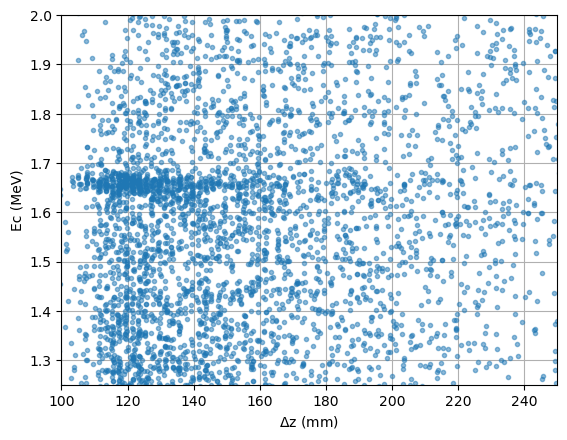

In [61]:
plt.plot(final_reco_summ.dZ, final_reco_summ.total_energy, '.', alpha = 0.5)
plt.xlim((100, 250))
plt.ylim((1.25, 2))
plt.xlabel(r'$\Delta$z (mm)')
plt.ylabel('Ec (MeV)')
plt.grid()

### Try applying a fiducial cut

In [64]:
rcut = 350
zmin, zmax = 500, 800
final_reco_summ_fid = final_reco_summ[(final_reco_summ.Z_bary > zmin) & (final_reco_summ.Z_bary < zmax) & (np.sqrt(final_reco_summ.X_bary ** 2 + final_reco_summ.Y_bary **2) < rcut)]

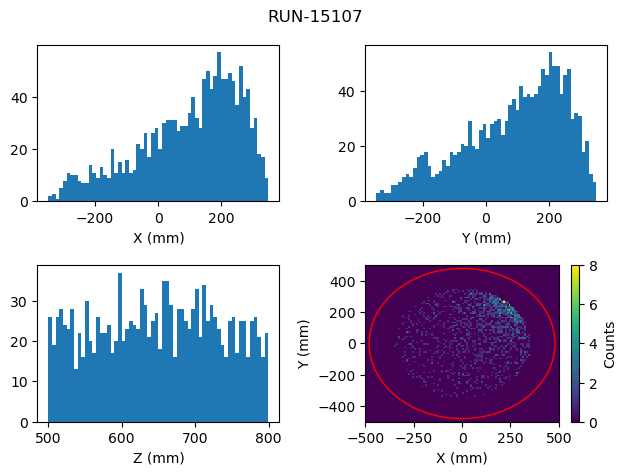

In [65]:
plot_coord_info(final_reco_summ_fid, run_number, c = ['X_bary', 'Y_bary', 'Z_bary'])

Text(0.5, 0, 'E (MeV)')

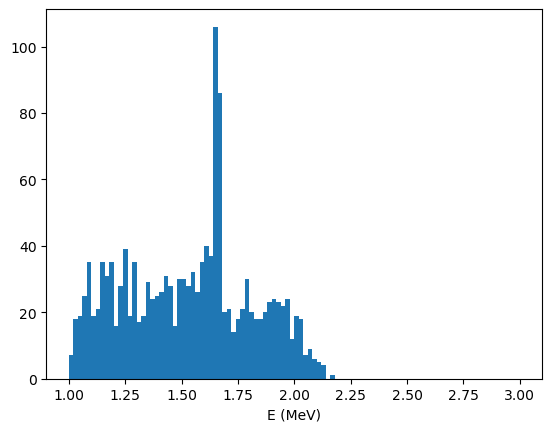

In [67]:
plt.hist(final_reco_summ_fid.total_energy, 100, (1, 3))
plt.xlabel('E (MeV)')

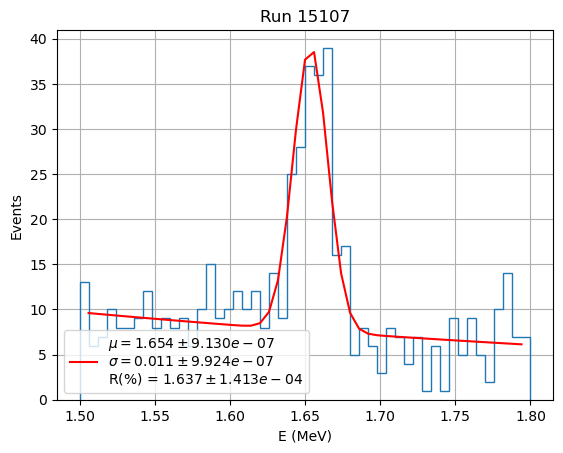

(array([3.15588946e+01, 1.65366022e+00, 1.14986120e-02, 9.95467065e+01,
        6.43938109e-01]),
 1.6374078244028296)

In [68]:
rang = (1.5, 1.8)
initial_params = [250, 1.65, 0.02, 1, 7]
bounds = ([0, 0, 0, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])

fit_and_plot_peaks_resolution(final_reco_summ_fid.total_energy, peak_fit, 50, rang, rang, initial_params, bounds, 'Run {}'.format(run_number), density = False)

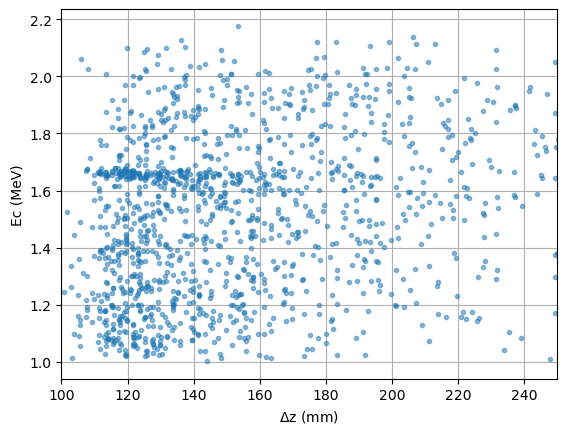

In [69]:
plt.plot(final_reco_summ_fid.dZ, final_reco_summ_fid.total_energy, '.', alpha = 0.5)
plt.xlim((100, 250))
# plt.ylim((1.4, 1.9))
plt.xlabel(r'$\Delta$z (mm)')
plt.ylabel('Ec (MeV)')
plt.grid()

### Checking hits

In [ ]:
# recohits = 

In [57]:
ds_reco = recohits[np.isin(list(recohits.event), E_corr_hand[(E_corr_hand > 1.5) & (E_corr_hand < 1.8)].index)]

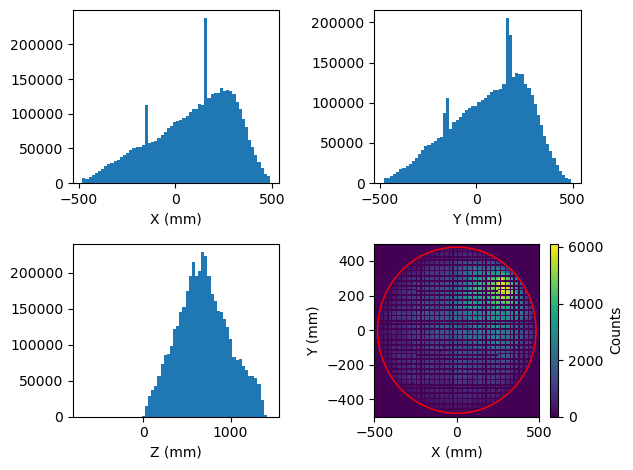

In [58]:
plt.subplot(2, 2, 1)
plt.hist(ds_reco.X, 60)
plt.xlabel('X (mm)')
plt.subplot(2, 2, 2)
plt.hist(ds_reco.Y, 60)
plt.xlabel('Y (mm)')
plt.subplot(2, 2, 3)
plt.hist(ds_reco.Z, 60)
plt.xlabel('Z (mm)')
plt.subplot(2, 2, 4)
hist = plt.hist2d(ds_reco.X, ds_reco.Y, bins=100, range = ((-500, 500), (-500, 500)), cmap='viridis')
plt.colorbar(hist[3], label='Counts')
plt.gca().add_patch(plt.Circle((0, 0), 480, color='r', fill=False, linewidth=1)) 
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.tight_layout()